In [34]:
import numpy as np

In [35]:
def discrete_differentiation(process):
    """
    Discretely differentiates a process.
    Process is a numpy array of shape (timesteps, samples)
    Returns the differentiated process, with Delta_t = Process_t - Process_{t-1}
    Delta_0 is given as zero
    """
    timesteps, samples = process.shape
    differences = (process[1:(timesteps), :] - process[0:(timesteps - 1), :])
    return np.vstack((np.zeros((1, samples)) , differences))

In [36]:
def generate_geometric_brownian(maturity, timesteps, samples, S_0, mu, sigma):
    """
    Generates stock processes according to Black Scholes model with
    drift mu and volatility sigma
    """
    brownians = np.sqrt(maturity / timesteps) * np.random.standard_normal((timesteps - 1, samples))
    brownians = np.vstack((np.zeros((1, samples)), brownians))
    differences = mu - sigma * sigma * 0.5 + sigma * brownians
    exponents = np.cumsum(differences, axis = 0)
    return S_0 * np.exp(exponents)

In [37]:
def black_scholes_alpha_process(maturity, stock_process, mu):
    """
    Returns the expected value of the final stock_price at maturity at each
    intermediate time_step based on a Black Scholes model
    (Essentially forward price assuming drift mu)
    """
    timesteps, samples = stock_process.shape
    return (stock_process.T * np.exp(mu * np.linspace(maturity, 0, timesteps))).T


In [38]:
def OW_optimal_impact(OW_beta, drift, alpha):
    """
    Takes a numpy array of alphas and drifts mu up to maturity T. 
    Returns an array of the optimal impact at each time point assuming an OW
    model, with decay parameter beta.
    """
    timesteps, samples = alpha.shape
    optimal_impact = 0.5 * (alpha + drift / OW_beta) # In Black Scholes, the drift is mu S_t. So the dimensions indeed match
    optimal_impact = np.vstack((optimal_impact[0:(timesteps - 1), :], np.zeros((1, samples))))
    return optimal_impact

In [39]:
def OW_trades_from_impact(impact, OW_beta, OW_lambda, maturity, starting_trades):
    """
    Returns the stock volume held at each time step, under optimal execution
    for the OW model of price impact for a general stochastic stock process.
    Takes a numpy array of (timesteps, samples) impact, and returns an array
    of the same size of the trades (at each time step, the integrated
    total position)
    """
    timesteps, samples = impact.shape
    impact_changes = discrete_differentiation(impact)

    trade_delta = (impact_changes + OW_beta * impact * maturity/timesteps) / OW_lambda

    trades = np.cumsum(trade_delta, axis = 0) + starting_trades

    return trades

In [40]:
def OW_impact_from_trades(trades, OW_beta, OW_lambda, maturity, starting_impact):
    """
    From a given trading strategy, returns the impact at each time step under
    an OW model of price impact.

    trades - Takes a numpy array of trades of size (timesteps, samples)
    starting_impact - starting Impact can either be an array of starting impacts, or a single
    figure if the same starting impact is desired across all positions
    OW_beta - Beta the constant decay parameter for impact
    OW_lambda - Lambda the linear impact parameter for trades
    maturity - Maturity, the total time over which trades occur
    """
    timesteps, samples = trades.shape

    delta_trades = discrete_differentiation(trades)
    delta_t = maturity/timesteps

    impact = np.zeros(shape = (timesteps, samples))
    impact[0, :] = starting_impact

    for i in range(1, timesteps):
        impact[i, :] = OW_lambda * delta_trades[i, :] - OW_beta * impact[i-1, :] * delta_t

    return impact



In [41]:
def fundamental_profit_and_loss(fundamental_stock_process, impact_process, trade_process):
    """
    Takes the fundamental (without impact of trades) stock process, the trades
    and the corresponding impact process and returns the evolution of the
    fundamental portfolio value over time. 

    (Given any trades, impact and fundamental stock process this should work, 
    so not impact model dependent)
    """

    # We want to calculate Y_t
    # We have equation
    # dY_t = Q_t dS_t - I_t dQ_t - 1/2 d [I, Q]_t
    # So we want to translate the above into this difference equation and then
    # integrate it
    stock_deltas = discrete_differentiation(fundamental_stock_process)
    trade_deltas = discrete_differentiation(trade_process)
    impact_deltas = discrete_differentiation(impact_process)
    covariation_deltas = trade_deltas * impact_deltas
    fundamental_value_deltas = trade_process * stock_deltas - impact_process * trade_deltas - 0.5 * covariation_deltas
    fundamental_value_process = np.cumsum(fundamental_value_deltas, axis = 0) + fundamental_stock_process[0, :] * trade_process[0, :]
    return fundamental_value_process




In [90]:
# # OW Optimal Execution Strategy - Currently not working
# # General parameters
# timesteps = 100
# samples = 2
# maturity = 1

# # Stock Parameters
# mu = 0.02
# sigma = 0.2
# S_0 = 1
# ADV = 10000000

# stocks = generate_geometric_brownian(maturity, timesteps, samples, S_0, mu, sigma)

# alpha_process = black_scholes_alpha_process(maturity, stocks, mu)

# # Impact parameters
# normalised_OW_beta = 0.05
# normalised_OW_lambda = 270

# unnormalised_OW_beta = normalised_OW_beta # Beta is just the speed of decay, this isn't affected by volume or sigma
# unnormalised_OW_lambda = normalised_OW_lambda * sigma / ADV

# impact_process = OW_optimal_impact(unnormalised_OW_beta, stocks * mu, alpha_process)

# # Portfolio parameters
# initial_trade_position = 100000

# trade_process = OW_trades_from_impact(impact_process, unnormalised_OW_beta, unnormalised_OW_lambda, maturity, initial_trade_position)


# profit_and_loss = fundamental_profit_and_loss(stocks, impact_process, trade_process)


# TWAP Strategy
# General parameters
timesteps = 20000
samples = 10000
maturity = 1

# Stock Parameters
mu = 0.02
sigma = 0.2
S_0 = 1
ADV = 50000

stocks = generate_geometric_brownian(maturity, timesteps, samples, S_0, mu, sigma)

alpha_process = black_scholes_alpha_process(maturity, stocks, mu)

# Impact parameters
normalised_OW_beta = 0.05
normalised_OW_lambda = 270

unnormalised_OW_beta = normalised_OW_beta # Beta is just the speed of decay, this isn't affected by volume or sigma
unnormalised_OW_lambda = normalised_OW_lambda * sigma / ADV

# Portfolio parameters
initial_trade_position = 100000

trade_process = np.tile(np.linspace(initial_trade_position, 0, num = timesteps), (samples, 1)).T

impact_process = OW_impact_from_trades(trade_process, unnormalised_OW_beta, unnormalised_OW_lambda, maturity, 0)


profit_and_loss = fundamental_profit_and_loss(stocks, impact_process, trade_process)

print(profit_and_loss[-1, :].mean())






[[1.00000000e+05 1.00000000e+05 1.00000000e+05 ... 1.00000000e+05
  1.00000000e+05 1.00000000e+05]
 [9.99949997e+04 9.99949997e+04 9.99949997e+04 ... 9.99949997e+04
  9.99949997e+04 9.99949997e+04]
 [9.99899995e+04 9.99899995e+04 9.99899995e+04 ... 9.99899995e+04
  9.99899995e+04 9.99899995e+04]
 ...
 [1.00005000e+01 1.00005000e+01 1.00005000e+01 ... 1.00005000e+01
  1.00005000e+01 1.00005000e+01]
 [5.00025001e+00 5.00025001e+00 5.00025001e+00 ... 5.00025001e+00
  5.00025001e+00 5.00025001e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[1.         1.         1.         ... 1.         1.         1.        ]
 [1.00072522 1.0003522  1.0001619  ... 1.00263212 1.00046213 1.00014357]
 [1.00004747 1.00131183 0.99804659 ... 1.00082269 1.00229278 1.00054872]
 ...
 [0.96747197 0.82265372 1.32231776 ... 1.07187939 1.00047308 1.15416644]
 [0.96707165 0.82222974 1.31805054 ... 1.0720601  1.00027518 1.15416431]
 [0.96653445 0.82283669 1.3196

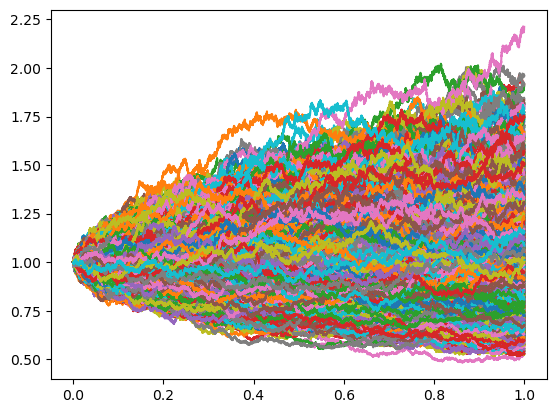

In [91]:
import matplotlib.pyplot as plt

plt.plot(np.linspace(0, maturity, timesteps), stocks)
plt.show()

In [92]:
black_scholes_alpha_process(maturity, stocks, mu)

array([[1.02020134, 1.02020134, 1.02020134, ..., 1.02020134, 1.02020134,
        1.02020134],
       [1.02094019, 1.02055963, 1.02036549, ..., 1.02288561, 1.02067178,
        1.02034679],
       [1.02024773, 1.02153763, 1.01820643, ..., 1.02103861, 1.02253839,
        1.0207591 ],
       ...,
       [0.9674739 , 0.82265536, 1.32232041, ..., 1.07188153, 1.00047508,
        1.15416875],
       [0.96707262, 0.82223056, 1.31805186, ..., 1.07206118, 1.00027618,
        1.15416546],
       [0.96653445, 0.82283669, 1.31968799, ..., 1.07004487, 1.00073134,
        1.1523493 ]])

In [93]:
plt.plot(np.linspace(0, maturity, timesteps), black_scholes_alpha_process(maturity, stocks, mu))
plt.plot(np.linspace(0, maturity, timesteps), stocks)
plt.show()

KeyboardInterrupt: 

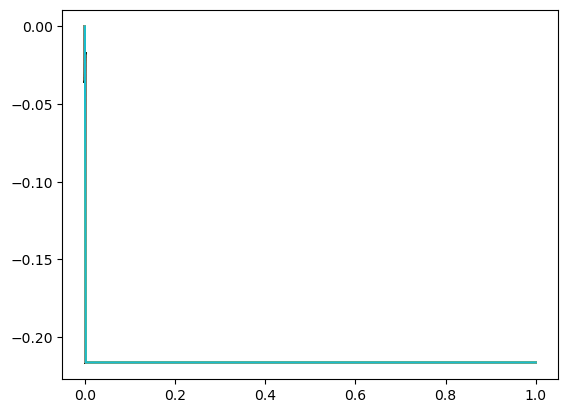

In [ ]:
plt.plot(np.linspace(0, maturity, timesteps), impact_process) # Maybe I should force the trades to be zero at the end for consistency...
plt.show()

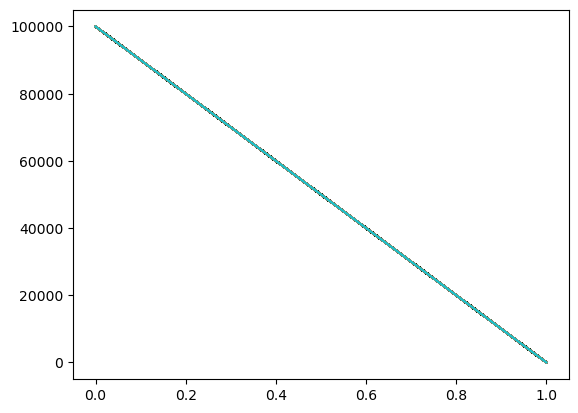

In [ ]:
plt.plot(np.linspace(0, maturity, timesteps), trade_process) # Maybe I should force the trades to be zero at the end for consistency...
plt.show()

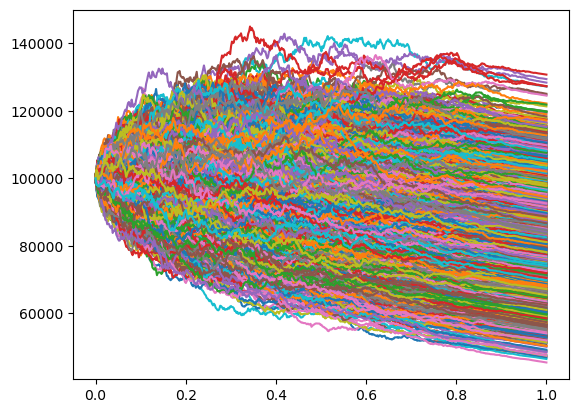

In [ ]:
plt.plot(np.linspace(0, maturity, timesteps), profit_and_loss)
plt.show()

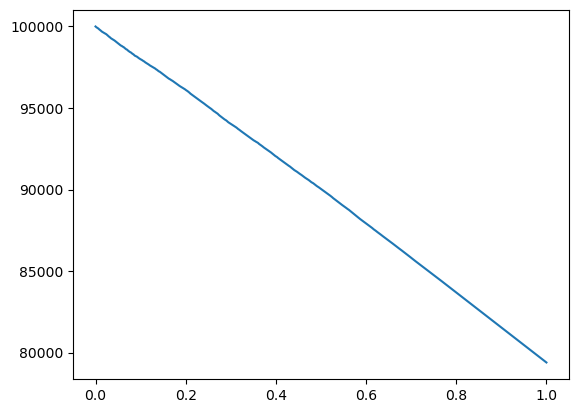

In [ ]:
plt.plot(np.linspace(0, maturity, timesteps), profit_and_loss.mean(axis = 1))
plt.show()

In [84]:
pfe = profit_and_loss[-1, :]
pfe.sort()
print(pfe[500])

62078.938468991655


In [85]:
# TWAP Strategy
# General parameters
timesteps = 1000
samples = 10000
maturity = 2

# Stock Parameters
mu = 0.02
sigma = 0.2
S_0 = 1
ADV = 50000

stocks = generate_geometric_brownian(maturity, timesteps, samples, S_0, mu, sigma)

alpha_process = black_scholes_alpha_process(maturity, stocks, mu)

# Impact parameters
normalised_OW_beta = 0.05
normalised_OW_lambda = 270

unnormalised_OW_beta = normalised_OW_beta # Beta is just the speed of decay, this isn't affected by volume or sigma
unnormalised_OW_lambda = normalised_OW_lambda * sigma / ADV

# Portfolio parameters
initial_trade_position = 100000

trade_process = np.tile(np.linspace(initial_trade_position, 0, num = timesteps), (samples, 1)).T
print(trade_process)
print(stocks)

impact_process = OW_impact_from_trades(trade_process, unnormalised_OW_beta, unnormalised_OW_lambda, maturity, 0)


profit_and_loss = fundamental_profit_and_loss(stocks, impact_process, trade_process)

pfe = profit_and_loss[-1, :]
pfe.sort()
print(pfe[500])


[[100000.        100000.        100000.        ... 100000.
  100000.        100000.       ]
 [ 99899.8998999  99899.8998999  99899.8998999 ...  99899.8998999
   99899.8998999  99899.8998999]
 [ 99799.7997998  99799.7997998  99799.7997998 ...  99799.7997998
   99799.7997998  99799.7997998]
 ...
 [   200.2002002    200.2002002    200.2002002 ...    200.2002002
     200.2002002    200.2002002]
 [   100.1001001    100.1001001    100.1001001 ...    100.1001001
     100.1001001    100.1001001]
 [     0.             0.             0.        ...      0.
       0.             0.       ]]
[[1.         1.         1.         ... 1.         1.         1.        ]
 [0.9946065  1.01624376 1.01421067 ... 1.00176097 0.99291058 1.00209885]
 [1.00489369 1.01744877 1.00758897 ... 1.00159052 0.98963548 1.00991302]
 ...
 [0.9084383  0.97087635 0.90526891 ... 0.83674014 0.85893108 0.98416014]
 [0.90794132 0.9569126  0.89368574 ... 0.84333929 0.85964253 0.97650184]
 [0.89899813 0.95409741 0.90377268 ... 0.849

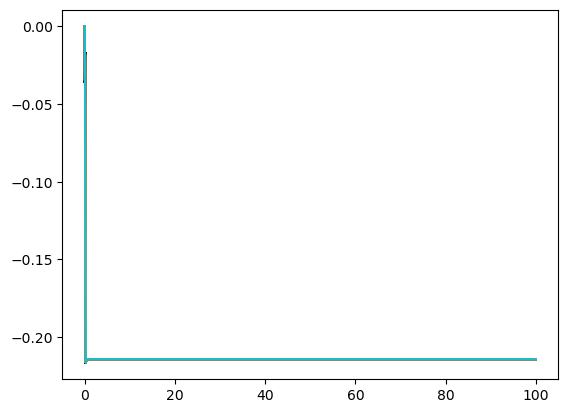

In [65]:
plt.plot(np.linspace(0, maturity, timesteps), impact_process) # Maybe I should force the trades to be zero at the end for consistency...
plt.show()

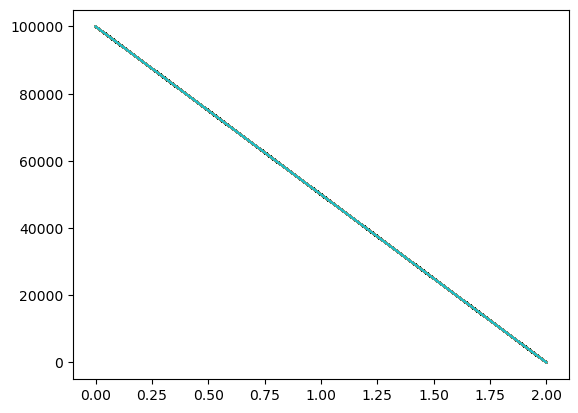

In [63]:
plt.plot(np.linspace(0, maturity, timesteps), trade_process) # Maybe I should force the trades to be zero at the end for consistency...
plt.show()